In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the CSV data
df = pd.read_csv('D:\\Projects\\hyperscan\\output\\statistics.csv')

# Display basic info and the first few rows
print(f"Total regexes processed: {len(df)}")
df.head()

Total regexes processed: 13619


,index,regex,num_literals,num_FAs
0,0,(30[0-5]\d|36\d{2}|38\d{2}) \d{4} \d{4} \d{2},26,2
1,1,(30[0-5]\d|36\d{2}|38\d{2})-\d{4}-\d{4}-\d{2},26,2
2,2,(30[0-5]\d|36\d{2}|38\d{2})\d{10},26,2
3,3,(3[4|7]\d{2}|2014|2149|2131|1800) \d{4} \d{4} ...,7,5
4,4,(3[4|7]\d{2}|2014|2149|2131|1800) \d{6} \d{5},7,5


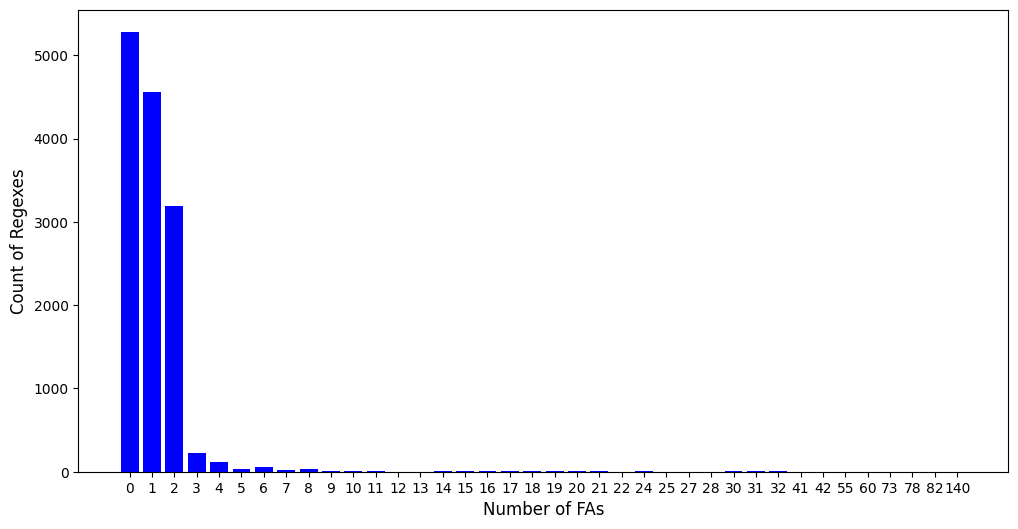

In [3]:
# Plot the distribution of the number of FAs
plt.figure(figsize=(12, 6))
fa_counts = df['num_FAs'].value_counts().sort_index()

x = list(fa_counts.index)
y = fa_counts.values
plt.bar(range(len(x)), y, color='blue')
plt.xticks(range(len(x)), x, rotation=0)
plt.xlabel('Number of FAs', fontsize=12)
plt.ylabel('Count of Regexes', fontsize=12)
plt.show()

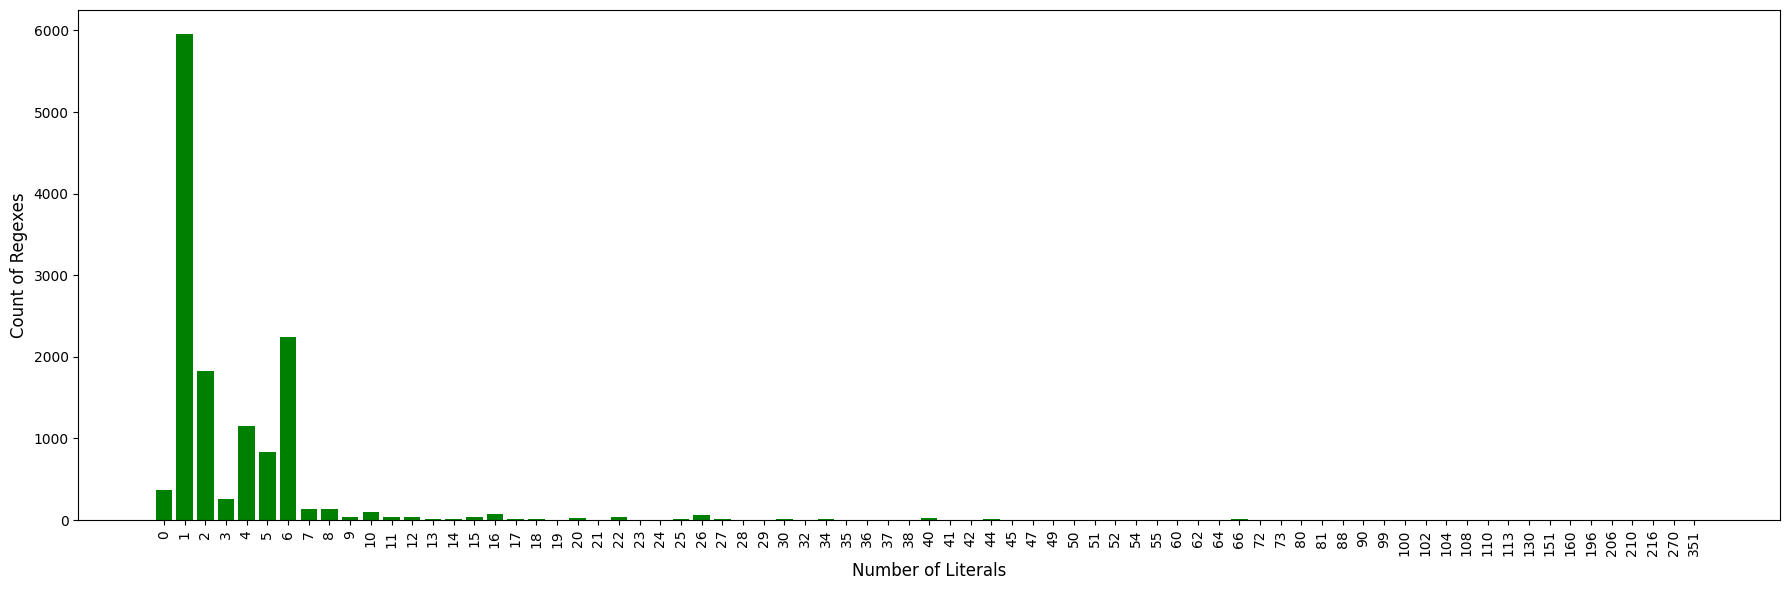

In [4]:
# Plot the distribution of the number of Literals
plt.figure(figsize=(18, 6))
literal_counts = df['num_literals'].value_counts().sort_index()

x = list(literal_counts.index)
y = literal_counts.values
plt.bar(range(len(x)), y, color='green')
plt.xticks(range(len(x)), x, rotation=90) # Rotate x-axis labels if there are many unique values
plt.xlabel('Number of Literals', fontsize=12)
plt.ylabel('Count of Regexes', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
# Aggregate stats from JSON dumps and write CSV to output/stats.csv
from pathlib import Path
import json
import csv
from regex_ast import countNodes, OUT_DIR

# Locate dump directory
dump_dir = Path(OUT_DIR) / 'dump'
if not dump_dir.exists():
    dump_dir = Path('output') / 'dump'

files = sorted(dump_dir.glob('*.json'), key=lambda p: (int(p.stem) if p.stem.isdigit() else float('inf'), p.stem))

rows = []
all_types = set()

for p in files:
    try:
        with p.open('r', encoding='utf-8') as fh:
            data = json.load(fh)
    except Exception as e:
        print(f"Skipping {p.name}: failed to load JSON: {e}")
        continue

    items = data if isinstance(data, list) else [data]

    for item in items:
        try:
            res = countNodes(item)
        except Exception as e:
            print(f"countNodes failed for {p.name}: {e}")
            res = {'regex': item.get('regex') if isinstance(item, dict) else None, 'total': 0, 'counts': []}

        regex = res.get('regex') or (item.get('regex') if isinstance(item, dict) else '')
        total = res.get('total', 0)
        counts_list = res.get('counts', [])
        counts_by_type = {d['type']: d['count'] for d in counts_list}

        # Prefer roles metadata for literal counts/lengths
        num_literals = 0
        longest_literal_len = 0
        role_literals = []
        if isinstance(item, dict):
            roles = item.get('roles') or []
            for r in roles:
                lit = None
                if isinstance(r, dict):
                    lit = r.get('literal')
                else:
                    lit = r
                if lit is None:
                    continue
                # treat placeholder values like "<none>" or empty strings as no literal
                if isinstance(lit, str):
                    if lit == '<none>' or lit == '':
                        continue
                    role_literals.append(lit)
                elif isinstance(lit, list):
                    try:
                        if all(isinstance(x, int) for x in lit):
                            role_literals.append(''.join(chr(x) for x in lit))
                        else:
                            role_literals.append(''.join(str(x) for x in lit))
                    except Exception:
                        role_literals.append(str(lit))
                else:
                    role_literals.append(str(lit))

        if role_literals:
            num_literals = len(role_literals)
            longest_literal_len = max(len(s) for s in role_literals)
        else:
            # Fallback: extract from the tree if roles are absent
            tree = item.get('tree') if isinstance(item, dict) and 'tree' in item else item

            def iter_literals(node):
                if node is None:
                    return
                if not isinstance(node, dict):
                    if isinstance(node, str):
                        yield node
                    return
                t = node.get('type')
                if t == 'Literal':
                    v = node.get('value')
                    if isinstance(v, str):
                        yield v
                    elif isinstance(v, list):
                        try:
                            yield ''.join(chr(x) for x in v)
                        except Exception:
                            yield str(v)
                    else:
                        yield str(v)
                    return
                if 'type' not in node and not node.get('children'):
                    v = node.get('value')
                    if isinstance(v, str):
                        yield v
                for ch in node.get('children', []) or []:
                    yield from iter_literals(ch)
                if 'child' in node and node.get('child') is not None:
                    yield from iter_literals(node.get('child'))

            for lit in iter_literals(tree):
                if lit is None:
                    continue
                s = lit if isinstance(lit, str) else str(lit)
                l = len(s)
                if l > longest_literal_len:
                    longest_literal_len = l

            # keep previous literal count as a fallback
            num_literals = counts_by_type.get('Literal', 0)

        all_types.update(counts_by_type.keys())
        row = {
            'file': p.name,
            'regex': regex,
            'total': total,
            'num_literals': num_literals,
            'longest_literal_len': longest_literal_len,
        }
        row.update(counts_by_type)
        rows.append(row)

# Prepare CSV columns
cols = ['file', 'regex', 'total', 'num_literals', 'longest_literal_len'] + sorted(all_types)
out_csv = Path(OUT_DIR) / 'stats.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)

with out_csv.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=cols)
    writer.writeheader()
    for r in rows:
        writer.writerow({c: r.get(c, 0) for c in cols})

print(f"Wrote {len(rows)} rows to {out_csv}")


Wrote 13618 rows to D:\Projects\hyperscan\output\stats.csv


Pearson r = 0.0650
Spearman rho = 0.4783


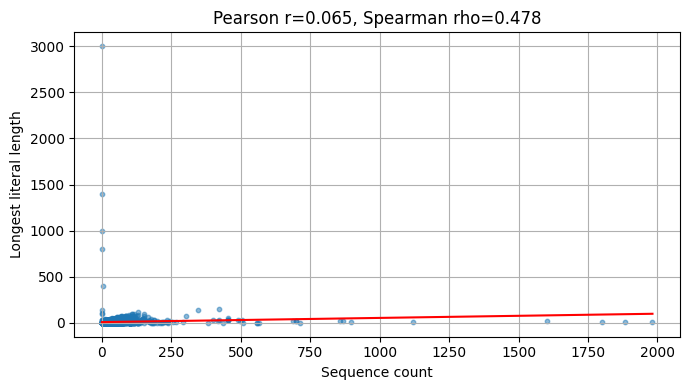

Wrote group stats to D:\Projects\hyperscan\output\seq_longest_literal_by_sequence.csv (rows: 207)


In [4]:
# Check correlation between `Sequence` count and longest literal length
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from regex_ast import OUT_DIR

stats_path = Path(OUT_DIR) / 'stats.csv'
if not stats_path.exists():
    print(f"stats.csv not found at {stats_path}")
else:
    df = pd.read_csv(stats_path)
    needed = ['Sequence', 'longest_literal_len']
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print('Missing columns in stats.csv:', missing)
    else:
        df['Sequence'] = pd.to_numeric(df['Sequence'], errors='coerce').fillna(0).astype(int)
        df['longest_literal_len'] = pd.to_numeric(df['longest_literal_len'], errors='coerce').fillna(0).astype(int)

        # focus on rows that actually have a literal length
        mask = df['longest_literal_len'] > 0
        X = df.loc[mask, 'Sequence']
        Y = df.loc[mask, 'longest_literal_len']

        if len(X) < 2:
            print('Not enough data points to compute correlation')
        else:
            pearson_r = np.corrcoef(X, Y)[0, 1]
            spearman_r = X.corr(Y, method='spearman')
            print(f'Pearson r = {pearson_r:.4f}')
            print(f'Spearman rho = {spearman_r:.4f}')

            # scatter + linear fit
            plt.figure(figsize=(7, 4))
            plt.scatter(X, Y, s=10, alpha=0.5)
            try:
                m, b = np.polyfit(X, Y, 1)
                xs = np.linspace(X.min(), X.max(), 200)
                plt.plot(xs, m * xs + b, color='red')
            except Exception:
                pass
            plt.xlabel('Sequence count')
            plt.ylabel('Longest literal length')
            plt.title(f'Pearson r={pearson_r:.3f}, Spearman rho={spearman_r:.3f}')
            plt.grid(True)
            out_img = Path(OUT_DIR) / 'seq_vs_longest_literal.png'
            plt.tight_layout()
            plt.savefig(out_img)
            plt.show()

            # group statistics by Sequence count
            group = df.groupby('Sequence')['longest_literal_len'].agg(['count', 'mean', 'median', 'max']).reset_index()
            out_group = Path(OUT_DIR) / 'seq_longest_literal_by_sequence.csv'
            group.to_csv(out_group, index=False)
            print(f'Wrote group stats to {out_group} (rows: {len(group)})')


Wrote group stats to D:\Projects\hyperscan\output\avg_num_literals_by_total.csv (rows: 441)


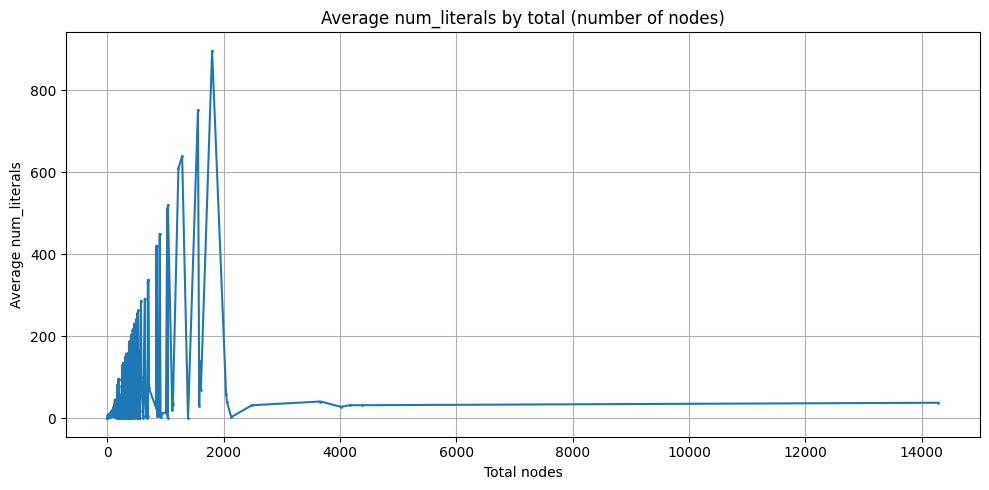

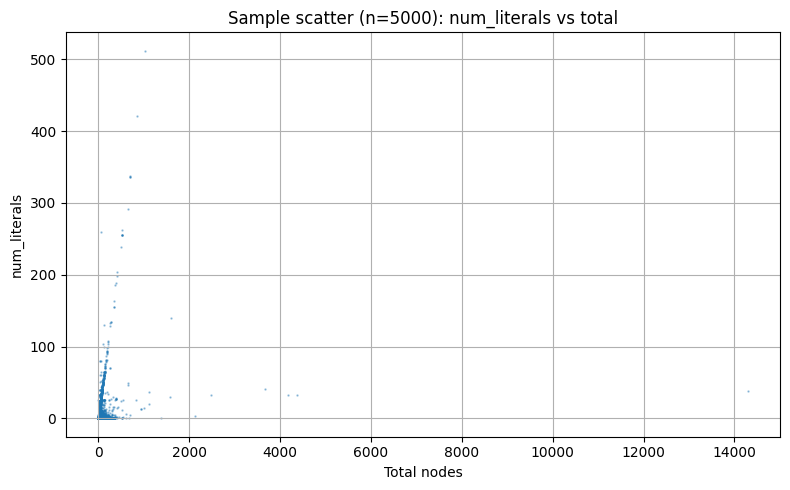

 total  count     mean  median      std
     0      4 6.750000     6.5 5.678908
     1     35 0.000000     0.0 0.000000
     2     87 0.344828     0.0 1.796816
     3     80 0.350000     0.0 1.814847
     4     56 2.857143     1.0 7.015382
     5     58 2.258621     1.0 3.913810
     6     70 2.342857     2.0 3.115579
     7     52 3.115385     2.0 3.507157
     8    151 2.125828     2.0 1.297714
     9    104 3.028846     2.0 3.755790
    10    103 3.097087     2.0 3.417127
    11    123 3.406504     3.0 3.458981
    12    100 3.940000     2.0 6.094906
    13     85 2.800000     2.0 2.313521
    14    133 3.654135     2.0 7.807383
    15     74 3.418919     2.0 3.637728
    16    129 3.410853     2.0 4.919052
    17     85 3.823529     2.0 3.556270
    18    139 3.748201     2.0 4.514218
    19     93 5.064516     5.0 4.104098


In [9]:
# Plot average `num_literals` grouped by `total` (number of nodes)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from regex_ast import OUT_DIR

stats_path = Path(OUT_DIR) / 'stats.csv'
if not stats_path.exists():
    stats_path = Path('output') / 'stats.csv'

if not stats_path.exists():
    print(f"stats.csv not found at {stats_path}")
else:
    df = pd.read_csv(stats_path)
    # Ensure numeric types
    df['total'] = pd.to_numeric(df['total'], errors='coerce').fillna(0).astype(int)
    df['num_literals'] = pd.to_numeric(df['num_literals'], errors='coerce').fillna(0).astype(int)

    # Group by total and compute statistics
    group = df.groupby('total')['num_literals'].agg(['count', 'mean', 'median', 'std']).reset_index().sort_values('total')

    out_group = Path(OUT_DIR) / 'avg_num_literals_by_total.csv'
    out_group.parent.mkdir(parents=True, exist_ok=True)
    group.to_csv(out_group, index=False)
    print(f"Wrote group stats to {out_group} (rows: {len(group)})")

    # Plot the mean num_literals vs total
    plt.figure(figsize=(10, 5))
    plt.plot(group['total'], group['mean'], marker='o', linestyle='-', markersize=1)
    plt.xlabel('Total nodes')
    plt.ylabel('Average num_literals')
    plt.title('Average num_literals by total (number of nodes)')
    plt.grid(True)
    out_img = Path(OUT_DIR) / 'avg_num_literals_by_total.png'
    plt.tight_layout()
    plt.savefig(out_img)
    plt.show()

    # Scatter a subsample of raw points to visualize spread
    n_sample = min(5000, len(df))
    if n_sample > 0:
        sample = df.sample(n=n_sample, random_state=1)
        plt.figure(figsize=(8, 5))
        plt.scatter(sample['total'], sample['num_literals'], s=0.5, alpha=0.4)
        plt.xlabel('Total nodes')
        plt.ylabel('num_literals')
        plt.title(f'Sample scatter (n={n_sample}): num_literals vs total')
        plt.grid(True)
        out_img2 = Path(OUT_DIR) / 'scatter_num_literals_vs_total.png'
        plt.tight_layout()
        plt.savefig(out_img2)
        plt.show()

    # Print a few rows of the grouped stats
    print(group.head(20).to_string(index=False))
